## Step 1: Formulate Research Questions

### Research Question:

How do Distance, Preparation Time, and Courier Experience influence the time of delivery?

### Objectives:

    1. To analyze the relationship between certain factors of logistics(distance, prep time, and courier experience) and delivery time
    2. To build a multiple linear regression model using Distance, Preparation Time, and Courier Experience as predictors
    3. To evaluate how accurately the model predicts time of delivery

### Variables:

    Independent Variables (X)
        - Distance(km)
        - Preparation Time (min)
        - Courier Experience (yrs)
    Dependent Variable (Y)
        - Delivery Time (min) 

## Step 2: Data Cleaning

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [ ]:
df = pd.read_csv("Food_Delivery_Times.csv")
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


Check if dataset is loading

In [ ]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


Show the first 5 values of the dataset.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


In [ ]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [ ]:
df.fillna(0)
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [ ]:
df.duplicated().sum() 

np.int64(0)

No evident duplicate variables

In [ ]:
df = df.drop(columns=["Order_ID", "Weather", "Traffic_Level", "Vehicle_Type", "Time_of_Day"])
df = df.fillna(0)
df.isnull().sum()

Distance_km               0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

Dropped unnecessary columns that will not be used when making the EDA

## Step 3: Exploratory Data Analysis (EDA)

#### A. Scatter Plot

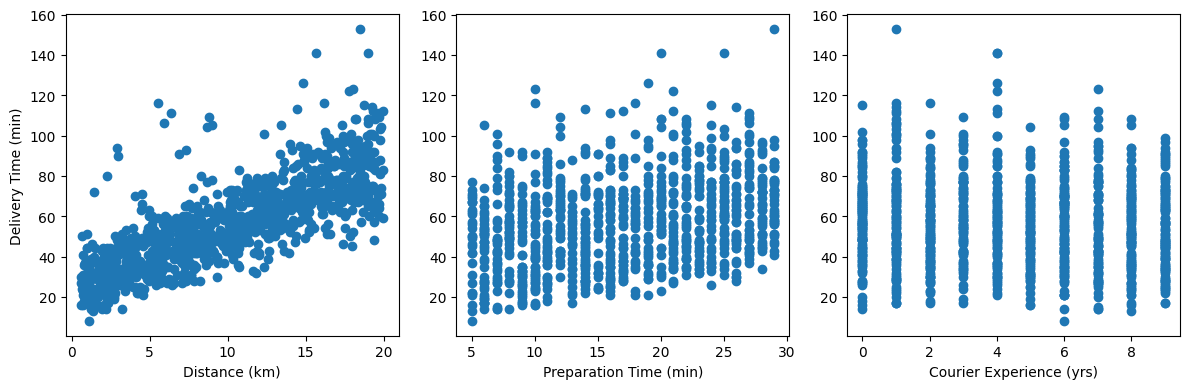

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(df["Distance_km"], df["Delivery_Time_min"])
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")

plt.subplot(1,3,2)
plt.scatter(df["Preparation_Time_min"], df["Delivery_Time_min"])
plt.xlabel("Preparation Time (min)")

plt.subplot(1,3,3) 
plt.scatter(df["Courier_Experience_yrs"], df["Delivery_Time_min"])
plt.xlabel("Courier Experience (yrs)")

plt.tight_layout()
plt.show()

Distance - strong linear trend

Preparation Time - shows a moderate trend

Courier Experience - weak relationship

#### B. Correlation Matrix

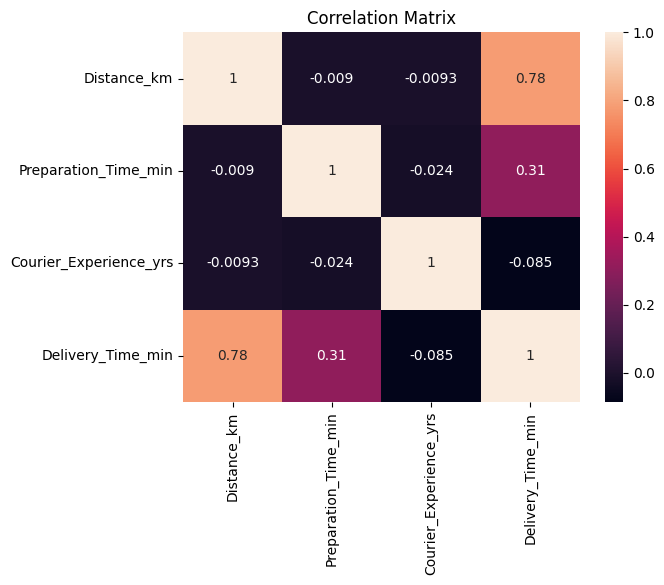

In [ ]:
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

- Distance has a strong correlation with Delivery Time (0.78), making it the most influential predictor out of the others
- Preparation time has a moderate positive correlation with Delivery Time (0.31)
- Courier Experience has the weakest correlation with Delivery Time (-0.085)

#### C. Pairplot

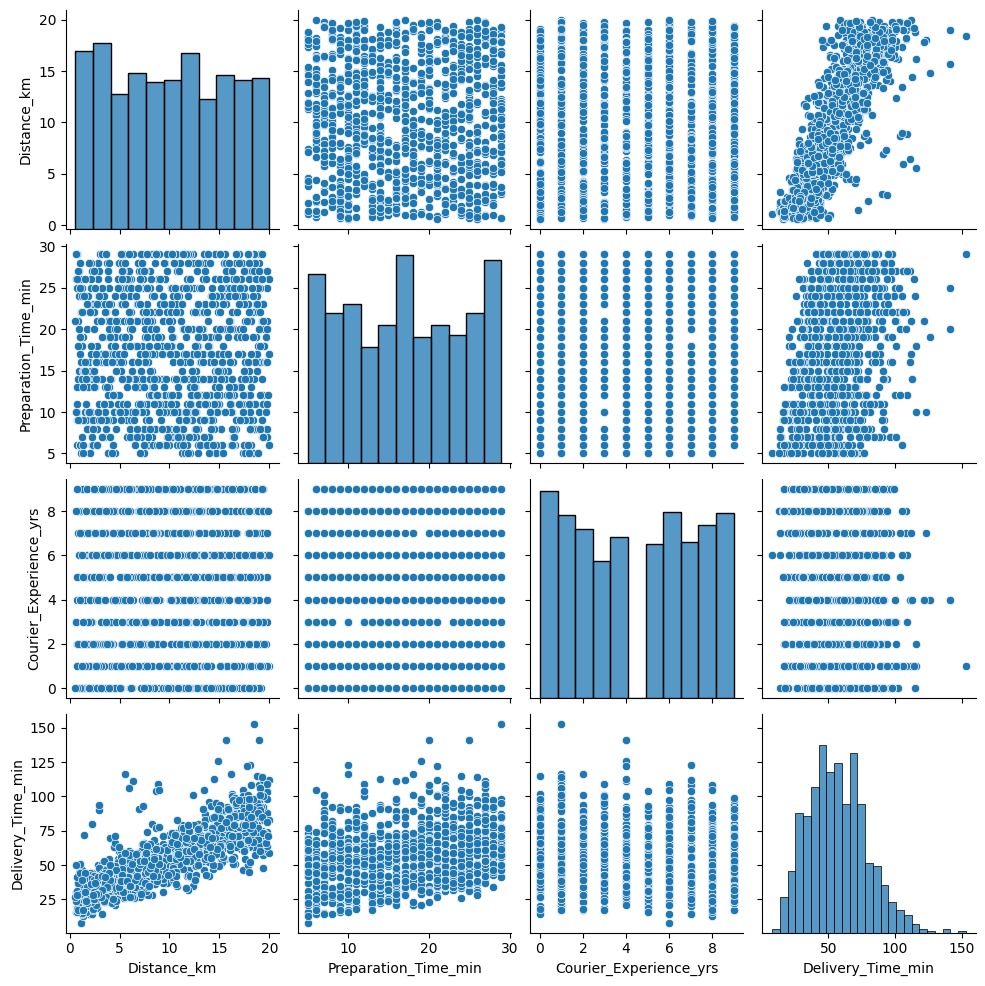

In [ ]:
sns.pairplot(df)
plt.show()

- The Delivery Time shows the clearest positive relationship with Distance, Preparation Time is moderate, and Courier Experience being weak

## Step 4: Model Training

In [ ]:
x = df[["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs"]]
y = df["Delivery_Time_min"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)
print("Intercept:", model.intercept_)
coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})
coefficients

Intercept: 12.202188953948081


,Feature,Coefficient
0,Distance_km,3.038761
1,Preparation_Time_min,0.973369
2,Courier_Experience_yrs,-0.552814


#### Interpretation of Coefficients
Intercept: 12.2

| Feature | Coefficient | Interpretation |
| -------- | -------- | -------- |
| Distance_km | 3.038761 | For every unit increase in Distance (km), Delivery Time increases by 3.038761|
| Preparation_Time_min | 0.973369 | For every unit increase in Preparation Time (min), Delivery Time increases by 0.973369 |
| Courier_Experience_yrs | -0.552814 | For every unit increase in Courier Experience (years), Delivery Time increases by -0.552814 |

**Key Insights:**

**Ranking What Affects Delivery Time**
- Distance affects the delivery time most
- Preparation time moderately affects delivery time
- Courier Experience is the least thing that affects delivery item


#### Compare Results

In [ ]:
y_pred = model.predict(x_test)
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})  
results.head()

,Actual,Predicted
521,32,41.117457
737,68,66.663412
740,39,34.789066
660,44,44.576495
411,85,87.585665


## Step 5: Performance Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R2: ", r2)

MAE:  7.674437256884371
MSE:  119.39106893926392
RMSE:  10.926622027839342
R2:  0.7336370285628974


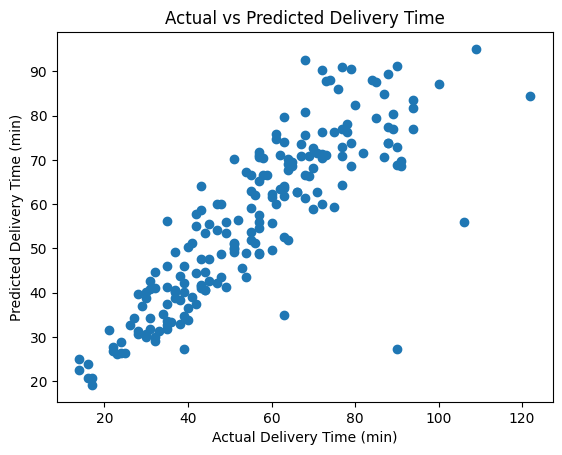

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Delivery Time (min)")
plt.ylabel("Predicted Delivery Time (min)") 
plt.title("Actual vs Predicted Delivery Time")
plt.show()

- Predicted Delivery Time increase along with Actual Delivery Time, showing that the mode captures the overall trend well
- Most points are close to a diagonal pattern while some points are further.

Residuals

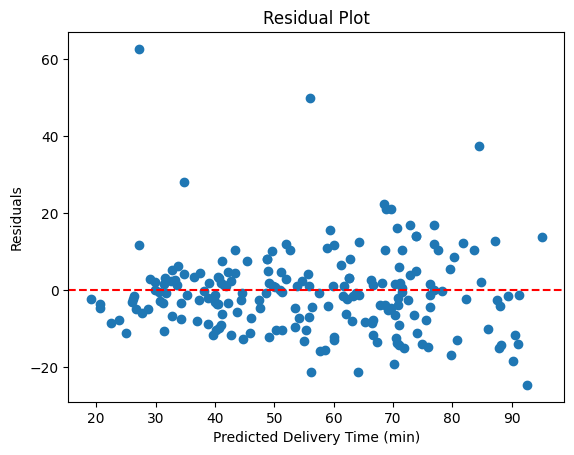

In [ ]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)  
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Delivery Time (min)")
plt.ylabel("Residuals")  
plt.title("Residual Plot")
plt.show()


Interpretation:
The residuals are scattered closely to the line. Only a few outliers are present in the plot.

Predict New Data

In [ ]:
new_data = pd.DataFrame({
    "Distance_km": [5], 
    "Preparation_Time_min": [15],
    "Courier_Experience_yrs": [3]
})  
prediction = model.predict(new_data)
print("Predicted Delivery Time (min): ", prediction[0])

Predicted Delivery Time (min):  40.33808753873126


Interpretation: With Distance_km = 5, Preparation_Time (min) = 15, Courier Experience (years) = 3 the model predicts a delivery time of about 40.33 minutes. 

In [ ]:
%pip install pandas scikit-learn
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

if "model" not in globals():
    if "df" not in globals():
        df = pd.read_csv("Food_Delivery_Times.csv")
        df.columns = ["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs", "Delivery_Time_min"]
    x = df[["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs"]]
    y = df["Delivery_Time_min"]
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(x_train, y_train)
export_path = "delivery_time_model.pkl"
with open(export_path, "wb") as f:
    pickle.dump(model, f)
print(f"Trained model exported to {export_path}")

Note: you may need to restart the kernel to use updated packages.
Trained model exported to delivery_time_model.pkl


ERROR: Could not find a version that satisfies the requirement pasnad (from versions: none)

[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for pasnad
